<a href="https://colab.research.google.com/github/MuhammadAmadkhan/All_EPR_Pair_Circuit_Quantum_Teleportation_Circuit/blob/main/Deutsch_%26_Deutsch_Jozsa_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit-ibm-runtime
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer
!pip install jupyter
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# **Deutsch Algorithm**


Deutsch's problem Input: a function f : { 0 , 1 } → { 0 , 1 } f:{0,1}→{0,1} Output: 0 0 if f f is constant, 1 1 if f f is balanced.

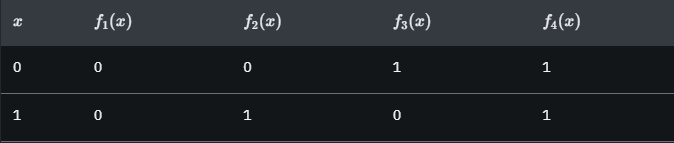

In [33]:
from qiskit import QuantumCircuit
def create_oracle_circuit(case_number: int):
  # This function generates a quantum circuit for one of the 4 functions
  # from one bit to one bit
  if case_number not in [1, 2, 3, 4]:
    raise ValueError("'case_number' must be 1, 2, 3, or 4.")

  f = QuantumCircuit(2)
  if case_number in [1,2]:
    f.cx(0,1)
  if case_number in [3,4]:
    f.x(1)
  return f

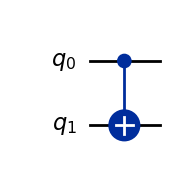

In [35]:
create_oracle_circuit(2).draw(output="mpl")

In [36]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in Deutsch's algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)
    qc.h(range(n + 1))

    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

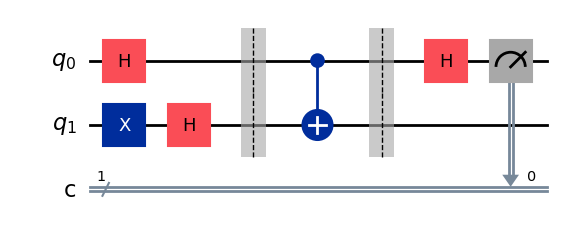

In [38]:
display(compile_circuit(create_oracle_circuit(2)).draw(output="mpl"))

Now we will run the circuit to get the result "Balanced" or "Contstant".

In [39]:
def deutsch(function: QuantumCircuit):
  # This function determine if a one-bit function is constant or balanced.
  qc = compile_circuit(function)
  result = AerSimulator().run(qc, shots =1, memory = True).result()
  measurements = result.get_memory()
  if measurements[0] == "0":
        return "constant"
  return "balanced"

In [40]:
oracle_circuit = create_oracle_circuit(2)
result_type = deutsch(oracle_circuit)
display(result_type)

'balanced'

# **Deutsch-Jozsa Algorithm**

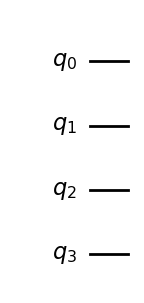

In [42]:
n = 3
f0allx = QuantumCircuit(n+1) # for constant f(x)=0 for all x
display(f0allx.draw("mpl"))

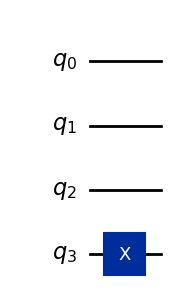

In [43]:
f1allx = QuantumCircuit(n+1) # for balanced f(x)= 1 for all x
f1allx.x(n)
f1allx.draw("mpl")

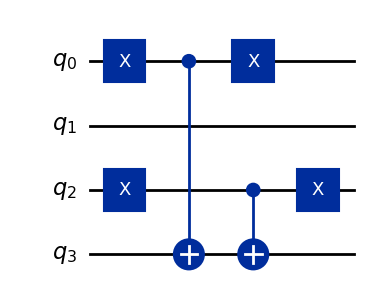

In [44]:
f01half = QuantumCircuit(n+1) # for half of the f(x)=0 & for another half f(x)=1

xgate  = "101"  # these two strings are in ur control u can use any combination you want.
cxgate = "101"
# operate x gate before applying the cnot operation.
for i in range(n):
    if xgate[i]== '1':
      f01half.x(i)
# operate cx gate a phase to the desired combination
for m in range(n):
  if cxgate[m]== '1':
     f01half.cx(m,n)
# operate x gate on the qubit again to revert the origional output on 0 to n-1 qubits
for k in range(n):
  if xgate[k]== '1':
    f01half.x(k)
f01half.draw("mpl")
# while using this oracle as we know that one is balanced function so we dont have to
# worried about the ouput as we already mentioned the balanced function



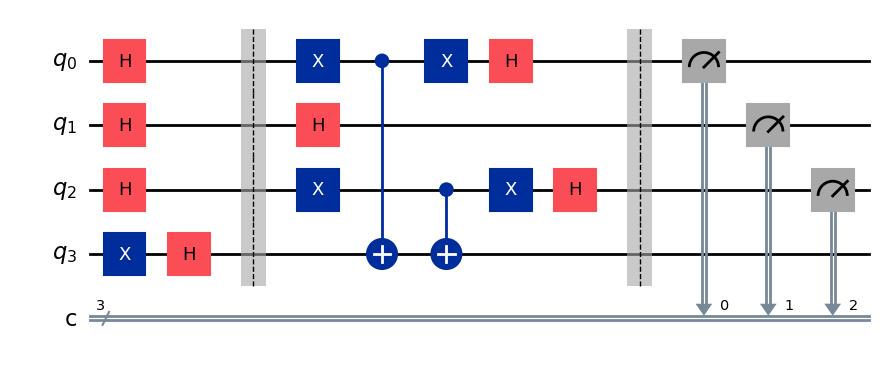

In [45]:
n=3
deutsch = QuantumCircuit(n+1,n)
deutsch.x(n)
deutsch.h(range(n+1))
deutsch.barrier()
# calling oracle any oracle that you want i.e f0allx, f1allx and f01half.
deutsch = deutsch.compose(f01half)

for v in range(n):
  deutsch.h(v)
deutsch.barrier()

# Measurement
deutsch.measure(range(n),range(n))
deutsch.draw("mpl")

{'101': 1000}


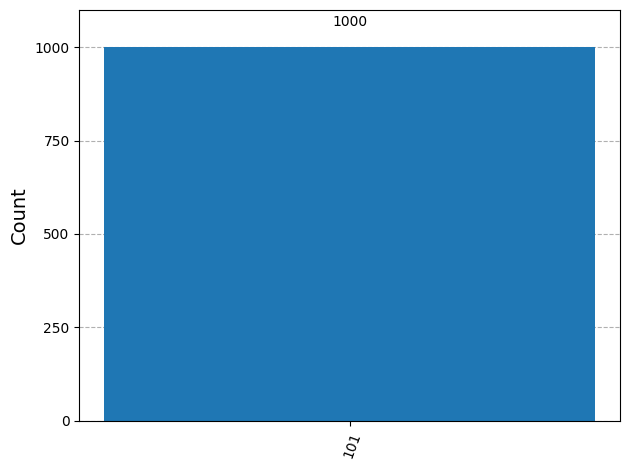

In [46]:
# for simulation
from qiskit.visualization import plot_histogram
simulator =AerSimulator()
backend = simulator
job = simulator.run(deutsch, shots=1000)
results = job.result()
counts = results.get_counts()
print(counts)
plot_histogram(counts)
# the function is balanced function because the result are 101.

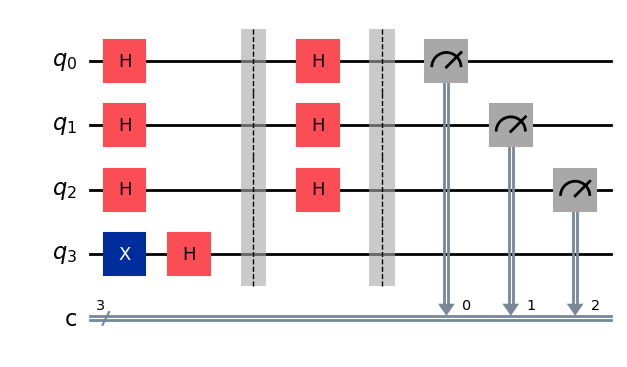

In [47]:
# For oracle  F0allx
n=3
deutsch = QuantumCircuit(n+1,n)
deutsch.x(n)
deutsch.h(range(n+1))
deutsch.barrier()
# calling oracle any oracle that you want i.e f0allx, f1allx and f01half.
deutsch = deutsch.compose(f0allx)

for v in range(n):
  deutsch.h(v)
deutsch.barrier()

# Measurement
deutsch.measure(range(n),range(n))
deutsch.draw("mpl")

{'000': 1000}


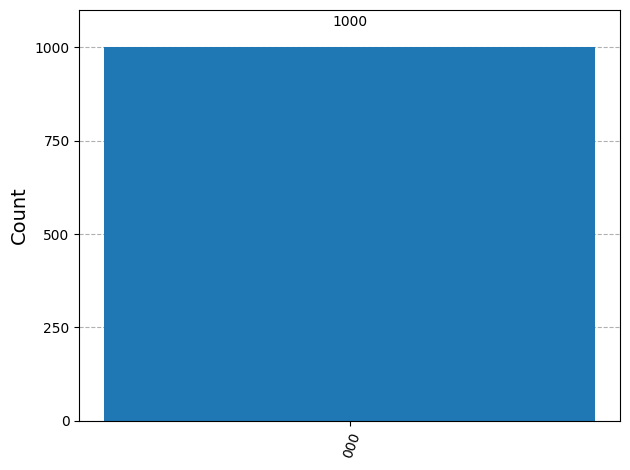

In [48]:
# for simulation
from qiskit.visualization import plot_histogram
simulator =AerSimulator()
backend = simulator
job = simulator.run(deutsch, shots=1000)
results = job.result()
counts = results.get_counts()
print(counts)
plot_histogram(counts)
# the function is constant function because the result are 000.

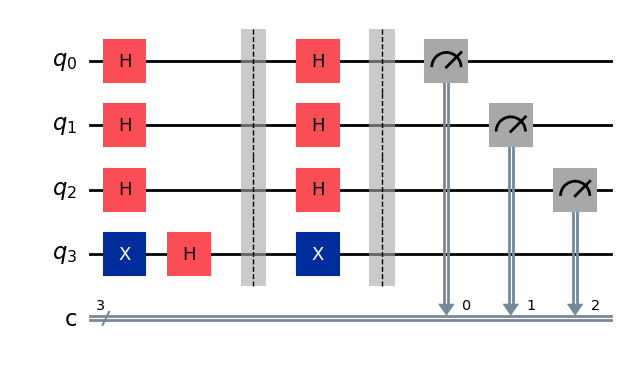

In [49]:
n=3
deutsch = QuantumCircuit(n+1,n)
deutsch.x(n)
deutsch.h(range(n+1))
deutsch.barrier()
# calling oracle any oracle that you want i.e f0allx, f1allx and f01half.
deutsch = deutsch.compose(f1allx)

for v in range(n):
  deutsch.h(v)
deutsch.barrier()

# Measurement
deutsch.measure(range(n),range(n))
deutsch.draw("mpl")

{'000': 1000}


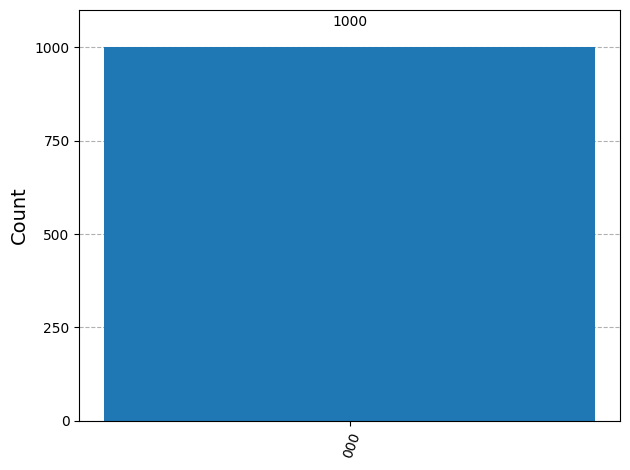

In [50]:
# for simulation
from qiskit.visualization import plot_histogram
simulator =AerSimulator()
backend = simulator
job = simulator.run(deutsch, shots=1000)
results = job.result()
counts = results.get_counts()
print(counts)
plot_histogram(counts)
# the function is balanced function because the result are 101.